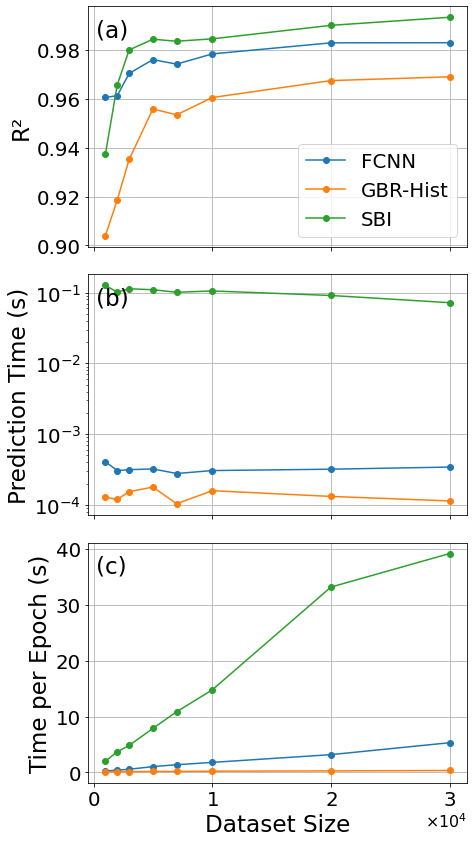

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Formatter for scientific notation on x-axis
sci_formatter = ScalarFormatter(useMathText=True)
sci_formatter.set_powerlimits((0, 0))  # force scientific notation

# ==========================
# Adjustable font sizes
# ==========================
scale = 1.1
label_fontsize = 21 * scale
title_fontsize = 24 * scale
legend_fontsize = 18 * scale
tick_fontsize = 18 * scale
annot_fontsize = 21 * scale

# Data for the three models (FCNN, GBM-Hist, SBI)
dataset_sizes = [1000, 2000, 3000, 5000, 7000, 10000, 20000, 30000]

# R² values
r2_fcnn = [0.9604879859, 0.9612072341, 0.9703234109, 0.9759557851, 0.9741126856, 0.97828722, 0.9828113717, 0.9828618964]
r2_gbm = [0.9040335779, 0.9186346078, 0.9351450492, 0.955794908, 0.9533941216, 0.9604630355, 0.9673837398, 0.9689277022]
r2_sbi = [0.9373768892, 0.9656598967, 0.9799196834, 0.9842843334, 0.9834644999, 0.9844382664, 0.9899576205, 0.9932540672]



# SBI Data
sbi_epochs = np.array([99, 152, 162, 117, 157, 83, 126, 143])
sbi_training_times = np.array([200.401946, 560.743127, 784.131467, 921.760194,
                               1705.526434, 1226.509686, 4179.572048, 5601.242231])
sbi_time_per_epoch = np.array([2.024262081, 3.68909952, 4.840317698, 7.878292256,
                               10.86322569, 14.77722513, 33.17120673, 39.16952609])
prediction_time_sbi = [0.126123, 0.101321, 0.113123, 0.109515,
                       0.100885, 0.105324, 0.090893, 0.0719]


# FCNN Data
fcnn_epochs = np.array([138, 81, 87, 144, 124, 136, 155, 79])
fcnn_training_times = np.array([34.580015, 34.669115, 49.876024, 150.960498,
                                171.831714, 244.950114, 494.277163, 420.393356])
fcnn_time_per_epoch = np.array([0.2505798188, 0.4280137654, 0.5732876322, 1.048336792,
                                1.385739629, 1.801103779, 3.188884923, 5.321434886])
prediction_time_fcnn = [0.000406, 0.000306, 0.000315, 0.000323,
                        0.000278, 0.000306, 0.00032, 0.000343]

# GBM-Hist Data
gbm_epochs = np.array([212, 221, 220, 235, 233, 248, 256, 250])
gbm_training_times = np.array([22.203884, 27.780781, 34.657354, 42.182194,
                               43.743006, 55.860503, 71.687775, 88.149718])
gbm_time_per_epoch = np.array([0.1047353019, 0.1257048914, 0.1575334273, 0.1794986979,
                               0.1877382232, 0.2252439637, 0.2800303711, 0.352598872])
prediction_time_gbm = [0.000128, 0.00012, 0.000154, 0.000179,
                       0.000104, 0.000159, 0.000132, 0.000114]

# ==========================
# Combined subplot figure
# ==========================
fig, axes = plt.subplots(3, 1, figsize=(7, 12), sharex=True)

# (a) R²
axes[0].plot(dataset_sizes, r2_fcnn, marker='o', label="FCNN")
axes[0].plot(dataset_sizes, r2_gbm, marker='o', label="GBR-Hist")
axes[0].plot(dataset_sizes, r2_sbi, marker='o', label="SBI")
axes[0].set_ylabel("R²", fontsize=label_fontsize)
axes[0].tick_params(labelsize=tick_fontsize)
axes[0].grid(True)
axes[0].text(0.02, 0.95, "(a)", transform=axes[0].transAxes, fontsize=annot_fontsize, va='top', ha='left')
axes[0].legend(loc='lower right', fontsize=legend_fontsize,
               framealpha=0.8, facecolor='white')

# (b) Prediction Time
axes[1].plot(dataset_sizes, prediction_time_fcnn, marker='o', label="FCNN")
axes[1].plot(dataset_sizes, prediction_time_gbm, marker='o', label="GBM-Hist")
axes[1].plot(dataset_sizes, prediction_time_sbi, marker='o', label="SBI")
axes[1].set_ylabel("Prediction Time (s)", fontsize=label_fontsize)
axes[1].set_yscale('log')
axes[1].tick_params(labelsize=tick_fontsize)
axes[1].grid(True)
axes[1].text(0.02, 0.95, "(b)", transform=axes[1].transAxes, fontsize=annot_fontsize, va='top', ha='left')

# (c) Time per Epoch
axes[2].plot(dataset_sizes, fcnn_time_per_epoch, marker='o', label="FCNN")
axes[2].plot(dataset_sizes, gbm_time_per_epoch, marker='o', label="GBM-Hist")
axes[2].plot(dataset_sizes, sbi_time_per_epoch, marker='o', label="SBI")
axes[2].set_ylabel("Time per Epoch (s)", fontsize=label_fontsize)
axes[2].set_xlabel("Dataset Size", fontsize=label_fontsize)
axes[2].tick_params(labelsize=tick_fontsize)
axes[2].grid(True)
axes[2].text(0.02, 0.95, "(c)", transform=axes[2].transAxes, fontsize=annot_fontsize, va='top', ha='left')
axes[2].xaxis.get_offset_text().set_fontsize(tick_fontsize*0.8)
axes[2].yaxis.get_offset_text().set_fontsize(tick_fontsize*0.8)



# Apply sci-notation formatter to x-axis (all subplots share x)
for ax in axes:
    ax.xaxis.set_major_formatter(sci_formatter)

plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/dataset_size.pdf", dpi=300, facecolor='white')
plt.show()


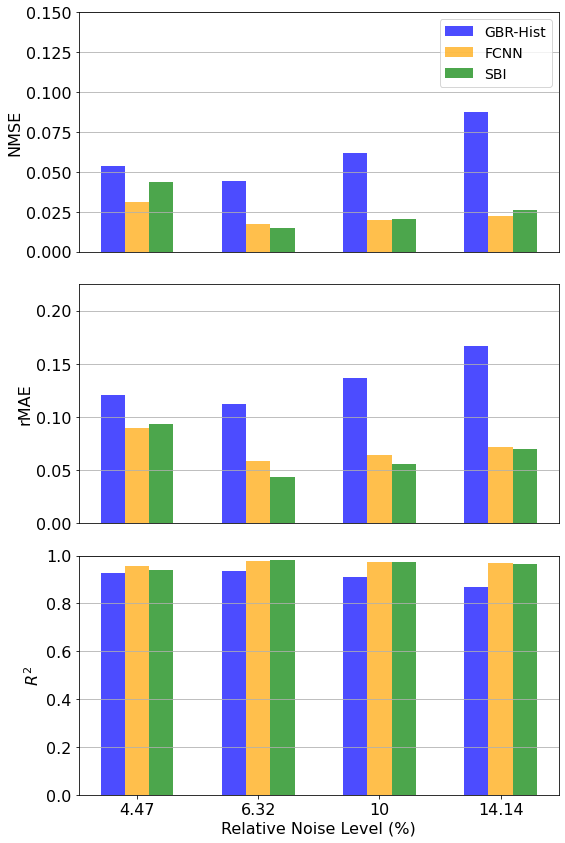

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==== Adjustable font size ====
base_fontsize = 16   # change this once to scale everything

# Data for FCNN, GBM-Hist, and SBI models
noise_levels = [4.47, 6.32, 10, 14.14]

# FCNN results
fcnn_mse = [0.031244166387682674, 0.017113730849660613, 0.01964889390945118, 0.022215993347311648]
fcnn_mae = [0.08988697324355015, 0.05897304421195917, 0.06456693967129817, 0.07175107038869485]
fcnn_r2   = [0.9562192802741052, 0.9768257625580401, 0.9733777331086237, 0.96983906145859]

# GBM-Hist results
gbm_mse = [0.05345368350898983, 0.04414786024568498, 0.06186121608331685, 0.08745308951840632]
gbm_mae = [0.12087397106634884, 0.11190682400291098, 0.13662210527647795, 0.16675653984408148]
gbm_r2   = [0.924995197258802, 0.9366272354683549, 0.9090768090043495, 0.8680559489418651]

# SBI results
sbi_mse = [0.043624384198197516, 0.015041731418487348, 0.020466176514585654, 0.025965803667753414]
sbi_mae = [0.09352532780845627, 0.04308684727825167, 0.05590203995463241, 0.06960905815805946]
sbi_r2   = [0.9382048759846137, 0.9800148508328324, 0.9726652438463887, 0.9648662575489075]

# Setting up the figure
plt.figure(figsize=(8, 12))
plt.rcParams.update({'font.size': base_fontsize})

bar_width = 0.2
x_indices = np.arange(len(noise_levels))

# === NMSE subplot ===
plt.subplot(3, 1, 1)
plt.bar(x_indices - bar_width, gbm_mse, bar_width, label='GBR-Hist', color='blue', alpha=0.7)   # left
plt.bar(x_indices, fcnn_mse, bar_width, label='FCNN', color='orange', alpha=0.7)                # middle
plt.bar(x_indices + bar_width, sbi_mse, bar_width, label='SBI', color='green', alpha=0.7)       # right
plt.ylabel('NMSE', fontsize=base_fontsize)
plt.legend(fontsize=base_fontsize-2)
plt.grid(True)
plt.xticks([])  # hide xticks
plt.ylim(0, 0.15)

# === rMAE subplot ===
plt.subplot(3, 1, 2)
plt.bar(x_indices - bar_width, gbm_mae, bar_width, label='GBR-Hist', color='blue', alpha=0.7)
plt.bar(x_indices, fcnn_mae, bar_width, label='FCNN', color='orange', alpha=0.7)
plt.bar(x_indices + bar_width, sbi_mae, bar_width, label='SBI', color='green', alpha=0.7)
plt.ylabel('rMAE', fontsize=base_fontsize)
plt.grid(True)
plt.xticks([])
plt.ylim(0, 0.225)

# === R² subplot ===
plt.subplot(3, 1, 3)
plt.bar(x_indices - bar_width, gbm_r2, bar_width, label='GBR-Hist', color='blue', alpha=0.7)
plt.bar(x_indices, fcnn_r2, bar_width, label='FCNN', color='orange', alpha=0.7)
plt.bar(x_indices + bar_width, sbi_r2, bar_width, label='SBI', color='green', alpha=0.7)
plt.xlabel('Relative Noise Level (%)', fontsize=base_fontsize)
plt.ylabel(r'$R^2$', fontsize=base_fontsize)
plt.xticks(x_indices, noise_levels, fontsize=base_fontsize)
plt.ylim(0, 1)
plt.grid(axis='y')

# Adjust layout
plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/noise_comparison.pdf", dpi=300, facecolor='white')
plt.show()


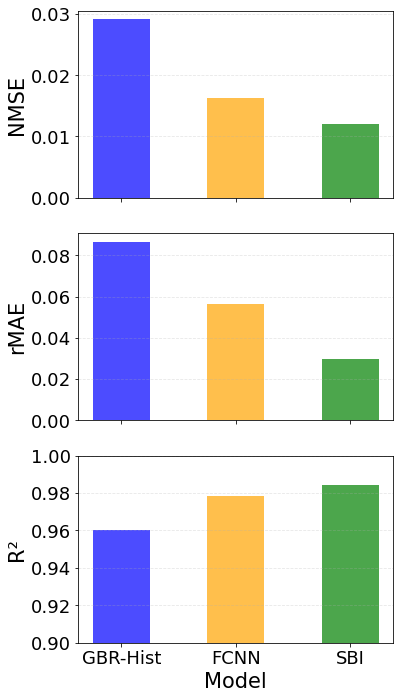

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Adjustable font sizes
# --------------------------
BASE_LABEL = 14
BASE_TICK  = 12
SCALE = 1.5   # adjust this multiplier as needed

label_fs = int(BASE_LABEL * SCALE)
tick_fs  = int(BASE_TICK  * SCALE)

# Data
models = ['GBR-Hist', 'FCNN', 'SBI']
colors = ['blue', 'orange', 'green']   # consistent color mapping

nmse = [0.02907916003246258, 0.016283886315404075, 0.011986410858568393]
rmae = [0.08651701482504255, 0.056520783494942536, 0.029791381055074357]
r2   = [0.9604630355068591, 0.9782872200222419, 0.9844382663854426]

# --------------------------
# Plot: 3 rows, shared x-axis
# --------------------------
fig, axes = plt.subplots(3, 1, figsize=(6, 10), sharex=True)

# (1) NMSE
axes[0].bar(models, nmse, color=colors, width=0.5, alpha=0.7)
axes[0].set_ylabel('NMSE', fontsize=label_fs)
axes[0].tick_params(axis='both', labelsize=tick_fs)
axes[0].grid(axis='y', linestyle='--', alpha=0.3)

# (2) rMAE
axes[1].bar(models, rmae, color=colors, width=0.5, alpha=0.7)
axes[1].set_ylabel('rMAE', fontsize=label_fs)
axes[1].tick_params(axis='both', labelsize=tick_fs)
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

# (3) R²
axes[2].bar(models, r2, color=colors, width=0.5, alpha=0.7)
axes[2].set_ylabel('R²', fontsize=label_fs)
axes[2].set_xlabel('Model', fontsize=label_fs)
axes[2].set_ylim(0.9, 1.0)
axes[2].tick_params(axis='both', labelsize=tick_fs)
axes[2].grid(axis='y', linestyle='--', alpha=0.3)

# Hide repeated x labels on upper subplots
for ax in axes[:-1]:
    ax.label_outer()

plt.tight_layout()
plt.savefig("/home/botingl/machine learning copy/Plots/whole_model.pdf", dpi=300, facecolor='white')
plt.show()


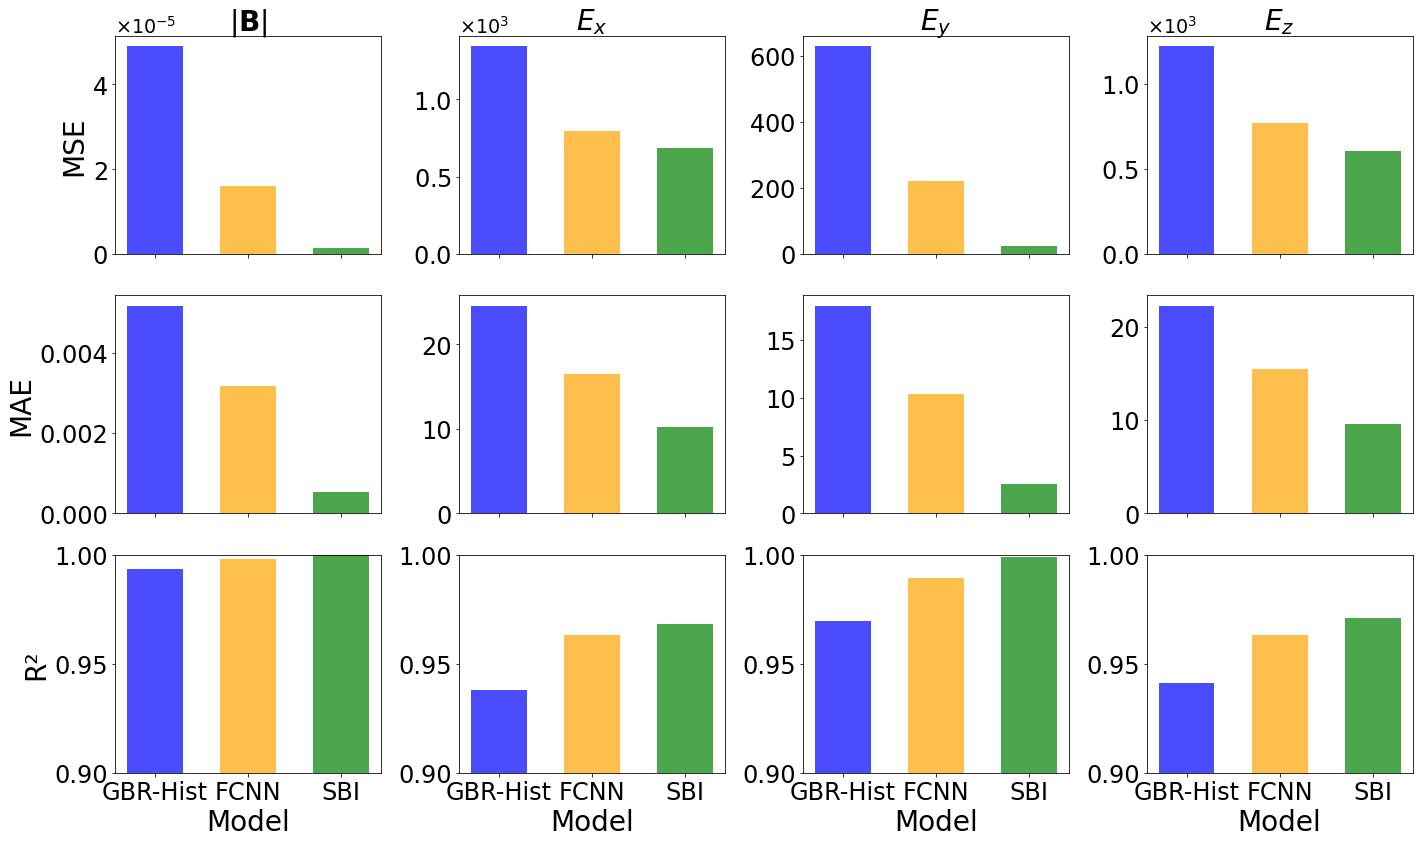

In [5]:
# Component-wise metrics
component_mse = [
    [4.898778351136203e-05, 1342.0474897109987, 628.951882432145, 1222.1178831986247],
    [1.6049456589906205e-05, 796.6419074043625, 222.32271120122545, 769.1323776866333],
    [1.3582062125663869e-06, 687.08302048258, 24.503040678443377, 604.6148142107404]
]
component_mae = [
    [0.00517109074940186, 24.567922517664435, 17.960644225167677, 22.27167545549036],
    [0.00316810244986263, 16.517346544251318, 10.314596248649451, 15.501679633298915],
    [0.000524068882530307, 10.163921054879767, 2.5533636657670775, 9.597371243329171]
]
component_r2 = [
    [0.9932707895685347, 0.9378496156403794, 0.9694538771067602, 0.9412778597117618],
    [0.9977953652326585, 0.9631074152578428, 0.9892025176360871, 0.9630435819623792],
    [0.9998134299052015, 0.9681811007901389, 0.9988099679598264, 0.9709485668866038]
]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Make formatter for scientific notation
sci_formatter = ScalarFormatter(useMathText=True)
sci_formatter.set_scientific(True)
sci_formatter.set_powerlimits((-3, 3))
sci_formatter.set_useOffset(False)



# ---------------------------
# Adjustable font sizes
# ---------------------------
BASE_LABEL = 14
BASE_TICK  = 12
BASE_TITLE = 14
SCALE = 2   # <- bump this (e.g., 1.3) to scale all fonts

label_fs = int(BASE_LABEL * SCALE)
tick_fs  = int(BASE_TICK  * SCALE)
title_fs = int(BASE_TITLE * SCALE)

# Models & consistent colors
models = ['GBR-Hist', 'FCNN', 'SBI']
model_colors = ['blue', 'orange', 'green']  # same mapping across all plots

components = ['$|\mathbf{B}|$', '$E_x$', '$E_y$', '$E_z$']
metrics = ['MSE', 'MAE', 'R²']

# --- your data objects must already exist:
# component_mse, component_mae, component_r2  (shape: 3 models × 4 components)

# 3 rows (MSE/MAE/R²) × 4 columns (B3/E1/E2/E3)
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex='col', sharey=False)
for axrow in axes:
    for ax in axrow:
        ax.tick_params(labelleft=True)  # force show y labels


# Apply to first row only
for ax in axes[0, :]:   # row 0, all 4 columns
    ax.yaxis.set_major_formatter(sci_formatter)

for i, metric in enumerate([component_mse, component_mae, component_r2]):
    for j, comp in enumerate(components):
        ax = axes[i, j]
        # heights for GBR-Hist, FCNN, SBI for this component
        vals = [metric[k][j] for k in range(len(models))]
        ax.bar(models, vals, color=model_colors, width=0.6, alpha=0.7)

        # Y label only on the leftmost column
        if j == 0:
            ax.set_ylabel(metrics[i], fontsize=label_fs)

        # Column titles only on the top row
        if i == 0:
            ax.set_title(comp, fontsize=title_fs)

        # R² range
        if metrics[i] == 'R²':
            ax.set_ylim(0.9, 1.0)
            ax.set_yticks([0.90, 0.95, 1.00])   # <- force exact ticks


        # ticks
        ax.tick_params(axis='both', labelsize=tick_fs)
        ax.xaxis.get_offset_text().set_fontsize(tick_fs*0.8)
        ax.yaxis.get_offset_text().set_fontsize(tick_fs*0.8)

# Only bottom row shows x labels (shared within each column)
for ax in axes[0, :]:
    ax.label_outer()  # hide x tick labels on top row
for ax in axes[1, :]:
    ax.label_outer()  # hide x tick labels on middle row
for ax in axes[2, :]:
    ax.set_xlabel('Model', fontsize=label_fs)

plt.tight_layout()
# Force y-ticks and labels visible on every subplot
for axrow in axes:
    for ax in axrow:
        ax.tick_params(labelleft=True)   # turn on tick labels
        for label in ax.get_yticklabels():
            label.set_visible(True)      # ensure visibility

plt.savefig("/home/botingl/machine learning copy/Plots/component_wise.pdf", dpi=300, facecolor='white')
plt.show()

